# Titanic Survival Classification - Exploratory Data Analysis

## Objective

The goal of this notebook is to explore the Titanic dataset, understand the structure and quality of the data, and identify patterns that may influence passenger survival.

The findings from this analysis will later be used for preprocessing and model development.

## 1. Import Libraries

---

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

## 2 Load Dataset

---

Load the Titanic dataset and create the initial dataframe used throughout the analysis.

In [2]:
df = pd.read_csv("../../data/raw/titanic.csv")

## 3 Initial Dataset Inspection
---

Inspect the dataset structure, feature types, and overall dataset dimensions.

In [3]:
df.head()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
0,1,22.0,1,7.2500,0,0,1,0
1,0,38.0,1,71.2833,1,0,0,1
2,0,26.0,0,7.9250,0,0,1,1
3,0,35.0,1,53.1000,1,0,0,1
4,1,35.0,0,8.0500,0,0,1,0


In [4]:
df.shape

(887, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 887 entries, 0 to 886
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          887 non-null    int64  
 1   age          887 non-null    float64
 2   family_size  887 non-null    int64  
 3   fare         887 non-null    float64
 4   1st_class    887 non-null    int64  
 5   2nd_class    887 non-null    int64  
 6   3rd_class    887 non-null    int64  
 7   survived     887 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.6 KB


In [6]:
df.describe()

,sex,age,family_size,fare,1st_class,2nd_class,3rd_class,survived
count,887.000000,887.000000,887.000000,887.00000,887.000000,887.000000,887.000000,887.000000
mean,0.645998,29.471443,0.908681,32.30542,0.243517,0.207441,0.549042,0.385569
std,0.478480,14.121908,1.615949,49.78204,0.429447,0.405703,0.497870,0.487004
min,0.000000,0.420000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,20.250000,0.000000,7.92500,0.000000,0.000000,0.000000,0.000000
50%,1.000000,28.000000,0.000000,14.45420,0.000000,0.000000,1.000000,0.000000
75%,1.000000,38.000000,1.000000,31.13750,0.000000,0.000000,1.000000,1.000000
max,1.000000,80.000000,10.000000,512.32920,1.000000,1.000000,1.000000,1.000000


### Initial Observations

- The dataset contains 887 rows and 8 columns: `sex`, `age`, `family_size`, `fare`, `1st_class`, `2nd_class`, `3rd_class`, and `survived`.

- The target variable is `survived`.

- All features are already represented numerically, which simplifies preprocessing.

- Age:
  - max = 80, min = 0.42, mean ≈ 29.5
  - Passenger ages range from infants to elderly passengers, with most passengers in young adult to middle-aged groups.

- Fare:
  - max = 512, mean ≈ 32
  - Fare is skewed with large outliers, so consider log-transform or robust scaling for modeling.

- Family size:
  - max = 10, mean ≈ 0.9
  - Most passengers traveled alone or in small groups; a few belong to larger families.

- Passenger class:
  - One-hot encoded as `1st_class`, `2nd_class`, `3rd_class`.
  - Distribution: ~24% 1st class, ~21% 2nd class, ~55% 3rd class.
  - Higher proportion of 3rd-class passengers may affect model calibration.

- Further analysis is needed for value ranges, duplicates, class balance, and feature–target relationships.

## 5. Missing Value Analysis

---

Analyze missing values across all features to identify preprocessing requirements before model training.

In [7]:
df.isnull().sum()

sex            0
age            0
family_size    0
fare           0
1st_class      0
2nd_class      0
3rd_class      0
survived       0
dtype: int64

### Observations

- No missing values

## 6. Target Variable Analysis

---

Investigate the distribution of the target variable (`survived`) to understand class balance.

In [8]:
df["survived"].value_counts()

survived
0    545
1    342
Name: count, dtype: int64

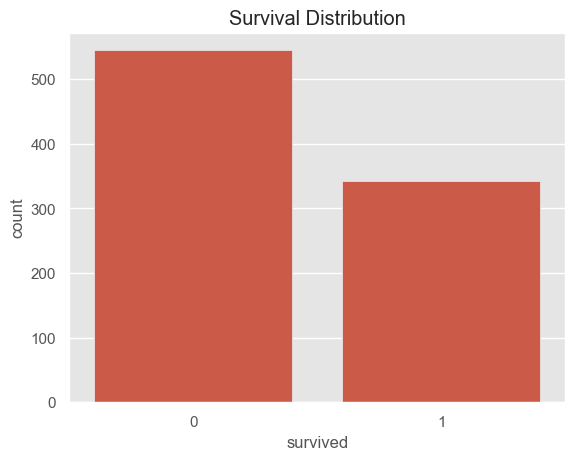

In [9]:
sns.countplot(data=df, x="survived")
plt.title("Survival Distribution")
plt.show()

### Observation

- The dataset is moderately imbalanced, with more passengers not surviving than surviving.

- Approximately 61% of passengers did not survive, while around 39% survived.

## 7 Feature Exploration

---

## 7.1 Survival Analysis by Sex

Analyze the relationship between passenger sex and survival probability.

In [10]:
df.groupby("sex")["survived"].mean()

sex
0    0.742038
1    0.190227
Name: survived, dtype: float64

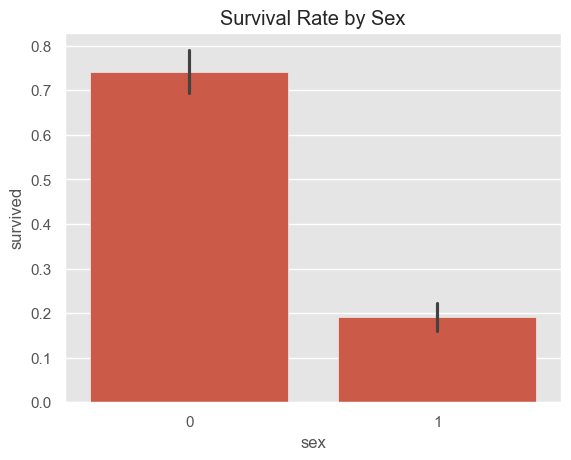

In [11]:
sns.barplot(data=df, x="sex", y="survived")
plt.title("Survival Rate by Sex")
plt.show()

### Observations


- Female passengers show a significantly higher survival rate than male passengers.

- 74% of female passengers survived, while only around 19% of male passengers.

- Sex appears to be a highly influential feature for predicting survival outcomes.

## 7.2 Age Distribution and Survival Analysis

Investigate passenger age distribution and its relationship to survival.

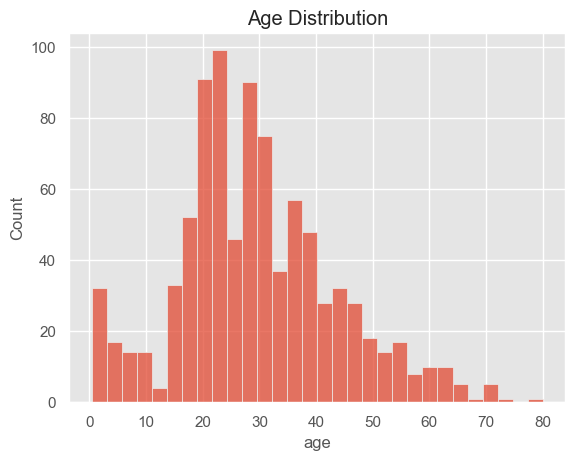

In [12]:
sns.histplot(df["age"], bins=30)
plt.title("Age Distribution")
plt.show()

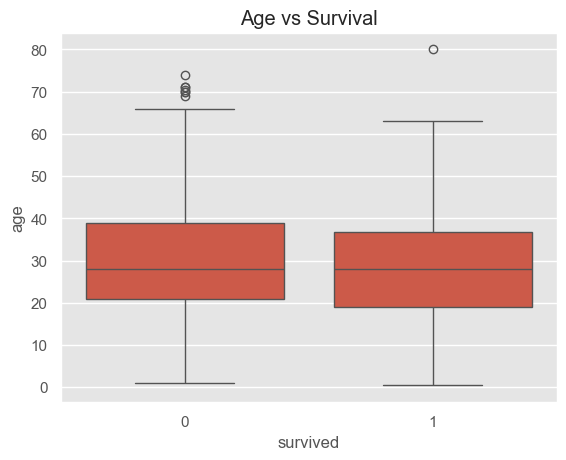

In [13]:
sns.boxplot(data=df, x="survived", y="age")
plt.title("Age vs Survival")
plt.show()

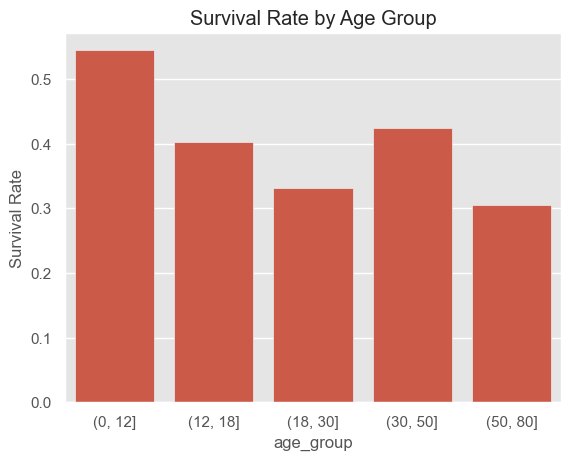

In [14]:
df["age_group"] = pd.cut(df["age"], bins=[0, 12, 18, 30, 50, 80])

survival_by_age = df.groupby("age_group")["survived"].mean().reset_index()

sns.barplot(data=survival_by_age, x="age_group", y="survived")

plt.ylabel("Survival Rate")
plt.title("Survival Rate by Age Group")
plt.show()

### Observations

- Age distribution:
  - The distribution is roughly bell-shaped with a concentration of passengers in their early 20s.
  - A small peak near age 0 indicates the presence of infants.
  - The distribution is sparse in the 12–14 range and increases again for young adults.

- Age vs survival:
  - The age distributions of survivors and non-survivors are similar, though survivors are on average slightly younger.

- Age group survival rates:
  - Children (0–12) show the highest survival rate (~55%).
  - Survival probability decreases for teenagers and young adults, increases modestly for those aged 30–50, and declines for older passengers (50+).

These results suggest that age alone is a weak linear predictor, but certain age groups (children and older adults) show meaningful differences in survival probability.

## 7.3 Passenger Class Analysis

Analyze whether passenger class correlates with survival probability.

In [15]:
survival_by_class = {
    "1st_class": df[df["1st_class"] == 1]["survived"].mean(),
    "2nd_class": df[df["2nd_class"] == 1]["survived"].mean(),
    "3rd_class": df[df["3rd_class"] == 1]["survived"].mean(),
}

survival_by_class

{'1st_class': np.float64(0.6296296296296297),
 '2nd_class': np.float64(0.47282608695652173),
 '3rd_class': np.float64(0.24435318275154005)}

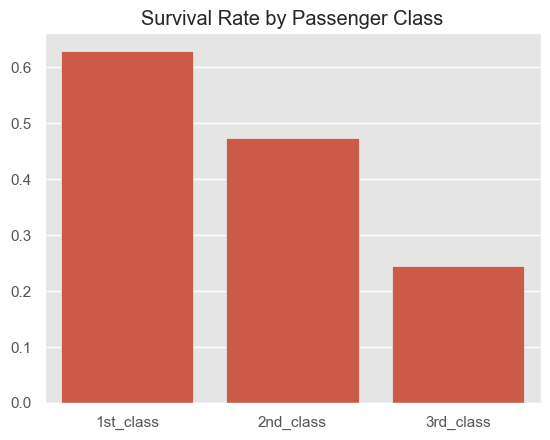

In [16]:
sns.barplot(x=list(survival_by_class.keys()), y=list(survival_by_class.values()))

plt.title("Survival Rate by Passenger Class")
plt.show()

### Observations

- 1st-class passengers have the highest survival rate (~63%).
- 2nd-class passengers have a moderate survival rate (~47%), slightly above the overall average.
- 3rd-class passengers have the lowest survival rate (~24%).

These results indicate a strong relationship between passenger class and survival, with a large gap between 1st and 3rd class survival rates.

## 7.4 Fare Analysis

Investigate fare distribution and its relationship to survival.

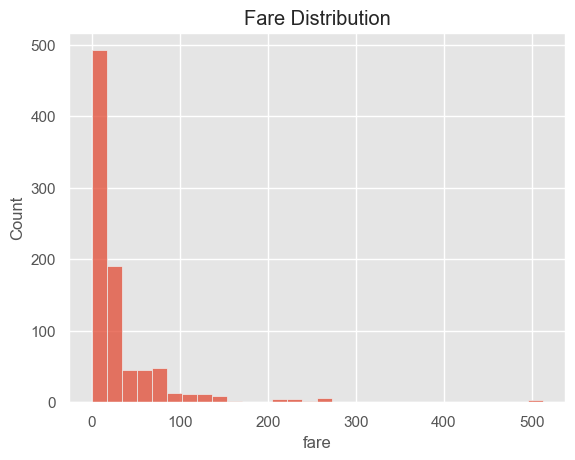

In [17]:
sns.histplot(df["fare"], bins=30)
plt.title("Fare Distribution")
plt.show()

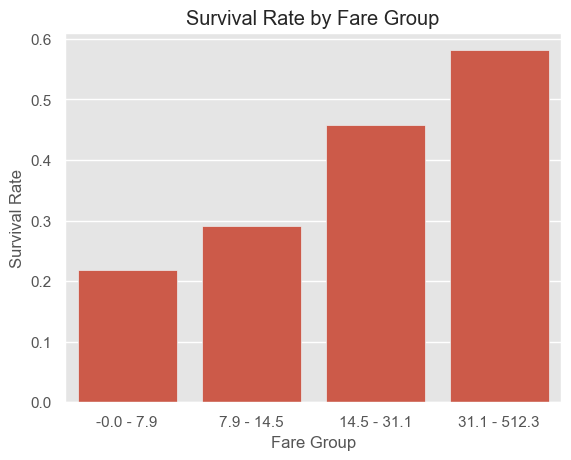

In [18]:
df["fare_group"] = pd.qcut(df["fare"], q=4)

df["fare_group"] = df["fare_group"].apply(lambda x: f"{x.left:.1f} - {x.right:.1f}")

fare_survival = df.groupby("fare_group")["survived"].mean().reset_index()

sns.barplot(data=fare_survival, x="fare_group", y="survived")

plt.ylabel("Survival Rate")
plt.xlabel("Fare Group")
plt.title("Survival Rate by Fare Group")

# plt.xticks(rotation=15)

plt.show()

### Observations

- Fare distribution is right-skewed: most passengers paid low fares, while a few paid very high fares (outliers up to ~512).
- Lower-fare passengers (lowest quartile) show a lower survival rate (~22%).
- Middle fare groups have gradual increases in survival (≈30% to ≈47%).
- Highest fare group shows substantially higher survival (~58%).

These results indicate a positive relationship between fare paid and survival probability; consider transforming or scaling `fare` for modeling.

## 7.5 Family Size Analysis

Analyze whether family size influences passenger survival.

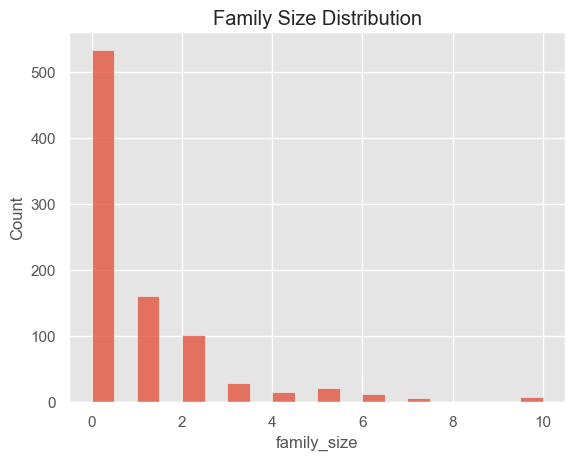

In [19]:
sns.histplot(df["family_size"], bins=20)
plt.title("Family Size Distribution")
plt.show()

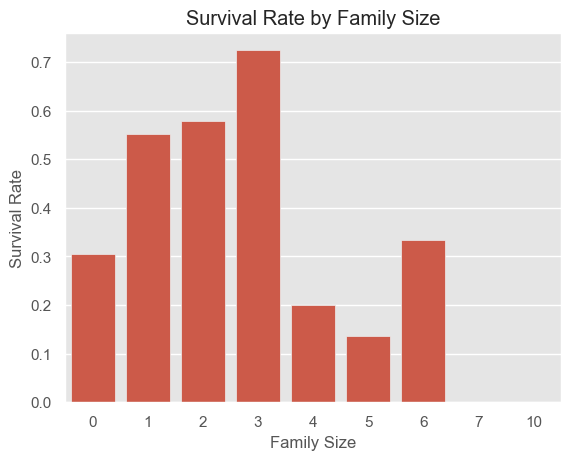

In [20]:
family_survival = df.groupby("family_size")["survived"].mean().reset_index()

sns.barplot(data=family_survival, x="family_size", y="survived")

plt.ylabel("Survival Rate")
plt.xlabel("Family Size")
plt.title("Survival Rate by Family Size")

plt.show()

### Observations

- Most passengers traveled alone or with one to two family members; a small number traveled with large families (up to 10).
- Passengers traveling with 1–3 family members show the highest survival rate (~60%).
- Solo travelers have a lower survival rate (~30%).

These results suggest family size may influence survival, but the effect could be confounded by sex and class (for example, many solo travelers are male). Consider stratified analyses or multivariable models to isolate the family-size effect.

## 8 Correlation Analysis

---

Investigate relationships between numerical features and identify potential feature dependencies.

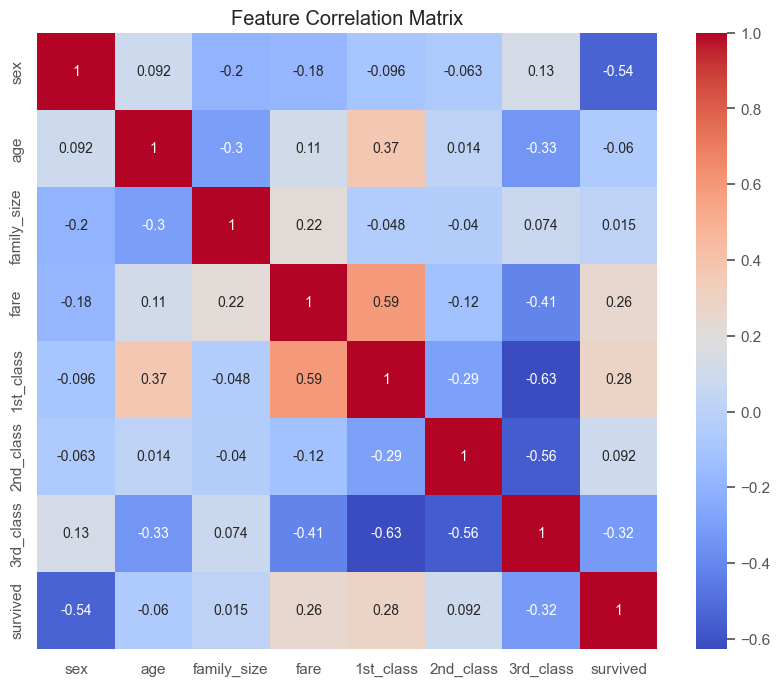

In [21]:
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

### Observations

- `sex` shows the strongest correlation with survival (-0.54), suggesting that passenger sex is a highly influential feature for predicting survival outcomes.

- `1st_class` positively correlates with survival (0.28), while `3rd_class` negatively correlates with survival (-0.32), indicating that passenger class likely played an important role in survival probability.

- `fare` shows a moderate positive correlation with survival (0.26), suggesting that passengers with more expensive tickets survived more frequently.

- `age` shows only a very weak linear correlation with survival (-0.06), indicating that age alone may not be a strong standalone linear predictor.


## 9 Preprocessing Considerations

---

Based on the exploratory analysis, the following preprocessing steps may be required before model training.

- Split the dataset into training and testing subsets.

- Separate features (`X`) from the target variable (`y`).

- Apply feature scaling to numerical features such as `age`, `fare`, and `family_size` before model training.

- Retain one-hot encoded passenger class features (`1st_class`, `2nd_class`, `3rd_class`) for model training.

- Evaluate whether strongly correlated features influence model performance.

- Use appropriate evaluation metrics to account for the moderate class imbalance in the target variable.

## 10 Conclusion

---


This exploratory data analysis investigated the structure, distributions, and feature relationships within the Titanic dataset.

Several features show meaningful relationships with passenger survival outcomes. In particular, passenger sex, passenger class, and fare demonstrate notable correlations with survival probability.

The dataset appears relatively clean and already numerically encoded, making it suitable for machine learning workflows with only limited preprocessing requirements.

The insights gathered during this analysis will guide the preprocessing and model development stages in the following notebooks.